# Previsão do nível do Rio do Sinos em São Leopoldo
Dados oriundos de estação telemétrica  n° 87382000 no site Hidroweb - ANA

O Objetivo é criar um modelo de Rede Neural Recorrente do tipo LSTM ( Long Short Time Memory) .

Com base nas 10 últimas observações do nivel do rio, prever o nível em 2, 4 e 8 horas. 

Dados são coletados a cada 15 em 15 minutos. 


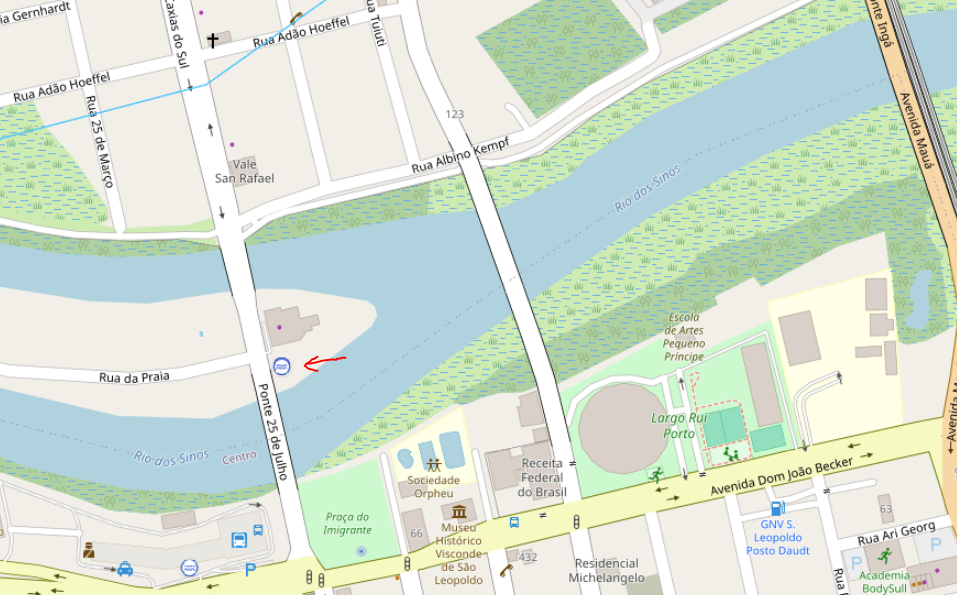

1. Importação de bibliotecas necessárias para todo o projeto

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, shapiro
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [2]:
# Carregamento dos dados
import pandas as pd

# Lê o arquivo Excel com dados de Data, Hora e Nível
df = pd.read_excel('87382000-SAO LEOPOLDO.xlsx')

# Combinação das colunas 'Data' e 'Hora' em uma única coluna datetime
df['datetime'] = pd.to_datetime(df['Data'].astype(str) + ' ' + df['Hora'].astype(str), errors='coerce')

#  Seleção das colunas relevantes e conversão para numérico
df1 = df[['datetime', 'Nível (cm)']].copy()
df1['Nível (cm)'] = pd.to_numeric(df1['Nível (cm)'], errors='coerce')

# Criação da série temporal com cópia para processamento
serie = df1.set_index('datetime')[['Nível (cm)']].copy()

# Preenchimento de valores faltantes via interpolação e preenchimento alternativo
serie['Nível (cm)'] = serie['Nível (cm)'].interpolate(method='linear')
serie['Nível (cm)'] = serie['Nível (cm)'].fillna(method='ffill').fillna(method='bfill')


C:\Users\AdmPDI\AppData\Local\Temp\ipykernel_28616\2743230391.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  serie['Nível (cm)'] = serie['Nível (cm)'].fillna(method='ffill').fillna(method='bfill')


3. Estatística descritiva 

4. Análise gráfica da série temporal 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237414 entries, 0 to 237413
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   datetime    237414 non-null  datetime64[ns]
 1   Nível (cm)  230408 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.6 MB
None
             datetime  Nível (cm)
0 2018-08-01 13:15:00       358.0
1 2018-08-01 13:30:00       358.0
2 2018-08-01 13:45:00       357.0
3 2018-08-01 14:00:00       357.0
4 2018-08-01 14:15:00       357.0


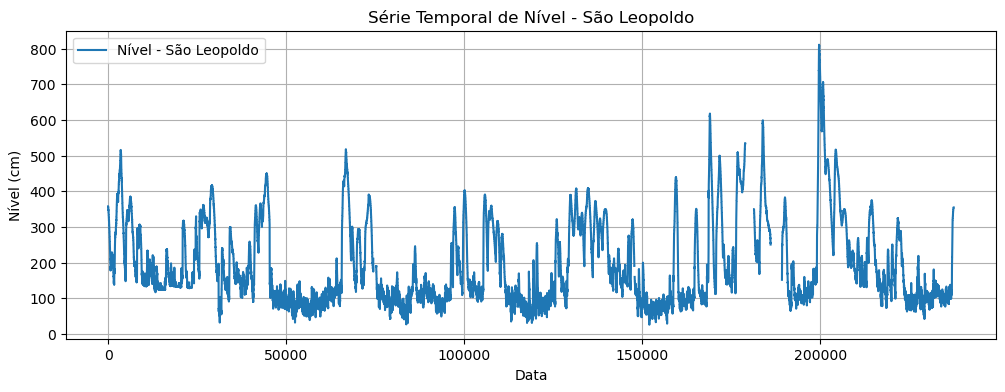

In [3]:
print(df1.info())
print(df1.head())

# 4. Plotar a série temporal de vazão
plt.figure(figsize=(12, 4))
plt.plot(df1.index, df1['Nível (cm)'], label='Nível - São Leopoldo')
plt.title('Série Temporal de Nível - São Leopoldo')
plt.xlabel('Data')
plt.ylabel("Nível (cm)")
plt.grid(True)
plt.legend()
plt.show()


In [5]:
df1

,datetime,Nível (cm)
0,2018-08-01 13:15:00,358.0
1,2018-08-01 13:30:00,358.0
2,2018-08-01 13:45:00,357.0
3,2018-08-01 14:00:00,357.0
4,2018-08-01 14:15:00,357.0
...,...,...
237409,2025-06-01 23:00:00,355.0
237410,2025-06-01 23:15:00,355.0
237411,2025-06-01 23:30:00,355.0
237412,2025-06-01 23:45:00,355.0


In [6]:
df1.isnull().sum().sum()


7006

In [7]:
df1= df1.interpolate(method='linear')


# Treinar modelo  720 min (12h) com cross validation.



C:\Users\AdmPDI\AppData\Local\Temp\ipykernel_28616\3050594475.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  serie['Nível (cm)'] = serie['Nível (cm)'].fillna(method='ffill').fillna(method='bfill')



📊 Avaliação via Cross-Validation Temporal:



C:\Users\AdmPDI\Documents\Conda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1237/1237 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
🔁 Fold 1: MAE = 9.27, RMSE = 12.89, R² = 0.9874


C:\Users\AdmPDI\Documents\Conda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

1237/1237 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
🔁 Fold 4: MAE = 7.73, RMSE = 11.78, R² = 0.9931


C:\Users\AdmPDI\Documents\Conda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1237/1237 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
🔁 Fold 5: MAE = 8.24, RMSE = 12.95, R² = 0.9923


C:\Users\AdmPDI\Documents\Conda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1483/1483 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

📉 Avaliação no trecho anômalo:
MAE = 17.10, RMSE = 24.14, R² = 0.9707


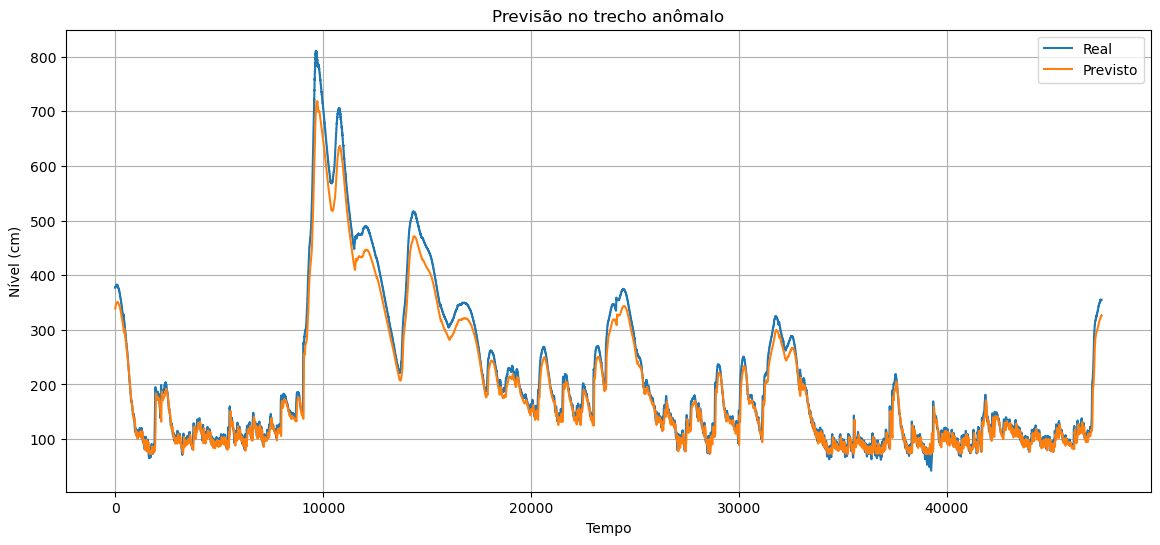

In [13]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ====================================
# 1. Pré-processamento
# ====================================
serie = df1[['Nível (cm)']].copy()
serie['Nível (cm)'] = serie['Nível (cm)'].interpolate(method='linear')
serie['Nível (cm)'] = serie['Nível (cm)'].fillna(method='ffill').fillna(method='bfill')

janela = 10
atraso = 32  # 8 horas
valores = serie.values

def cria_janelas(series, janela=10, atraso=32):
    X, y = [], []
    for i in range(len(series) - janela - atraso):
        X.append(series[i:i+janela])
        y.append(series[i+janela+atraso-1])
    return np.array(X), np.array(y)

X_all, y_all = cria_janelas(valores, janela, atraso)

# ====================================
# 2. Cross-validation temporal
# ====================================
tscv = TimeSeriesSplit(n_splits=5)
print("\n📊 Avaliação via Cross-Validation Temporal:\n")

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_all)):
    scaler = MinMaxScaler()
    
    X_train_raw = X_all[train_idx]
    y_train_raw = y_all[train_idx]
    X_test_raw = X_all[test_idx]
    y_test_raw = y_all[test_idx]
    
    # Normalização
    X_train = scaler.fit_transform(X_train_raw.reshape(-1, 1)).reshape(X_train_raw.shape)
    y_train = scaler.transform(y_train_raw.reshape(-1, 1))
    X_test = scaler.transform(X_test_raw.reshape(-1, 1)).reshape(X_test_raw.shape)
    y_test = scaler.transform(y_test_raw.reshape(-1, 1))

    # EarlyStopping
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # Modelo com Dropout
    model = Sequential([
        LSTM(50, activation='tanh', dropout=0.0, recurrent_dropout=0.0, input_shape=(janela, 1)),
        Dropout(0.0),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=30, batch_size=32,
              validation_split=0.1, callbacks=[early_stop], verbose=0)

    y_pred_scaled = model.predict(X_test)
    y_pred_inv = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test)

    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
    r2 = r2_score(y_test_inv, y_pred_inv)

    print(f"🔁 Fold {fold+1}: MAE = {mae:.2f}, RMSE = {rmse:.2f}, R² = {r2:.4f}")

# ====================================
# 3. Avaliação no trecho anômalo
# ====================================
n_total = len(serie)
n_anom = int(n_total * 0.2)

serie_anomalo = serie.iloc[-n_anom:]
serie_normal = serie.iloc[:-n_anom]

X_train_raw, y_train_raw = cria_janelas(serie_normal.values, janela, atraso)
X_test_raw, y_test_raw = cria_janelas(serie_anomalo.values, janela, atraso)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw.reshape(-1, 1)).reshape(X_train_raw.shape)
y_train = scaler.transform(y_train_raw.reshape(-1, 1))
X_test = scaler.transform(X_test_raw.reshape(-1, 1)).reshape(X_test_raw.shape)
y_test = scaler.transform(y_test_raw.reshape(-1, 1))

# Modelo com Dropout e EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model = Sequential([
    LSTM(50, activation='tanh', dropout=0.1, recurrent_dropout=0.1, input_shape=(janela, 1)),
    Dropout(0.1),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=30, batch_size=32,
          validation_split=0.1, callbacks=[early_stop], verbose=0)

y_pred_scaled = model.predict(X_test)
y_pred_inv = scaler.inverse_transform(y_pred_scaled)
y_test_inv = scaler.inverse_transform(y_test)

mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
r2 = r2_score(y_test_inv, y_pred_inv)

print("\n📉 Avaliação no trecho anômalo:")
print(f"MAE = {mae:.2f}, RMSE = {rmse:.2f}, R² = {r2:.4f}")

plt.figure(figsize=(14,6))
plt.plot(y_test_inv, label="Real")
plt.plot(y_pred_inv, label="Previsto")
plt.title("Previsão no trecho anômalo")
plt.xlabel("Tempo")
plt.ylabel("Nível (cm)")
plt.legend()
plt.grid(True)
plt.show()


In [21]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_all)):
    print(f"Fold {fold+1}:")
    print(f"  Treino: {len(train_idx)} amostras")
    print(f"  Teste : {len(test_idx)} amostras\n")


Fold 1:
  Treino: 39561 amostras
  Teste : 39559 amostras

Fold 2:
  Treino: 79120 amostras
  Teste : 39559 amostras

Fold 3:
  Treino: 118679 amostras
  Teste : 39559 amostras

Fold 4:
  Treino: 158238 amostras
  Teste : 39559 amostras

Fold 5:
  Treino: 197797 amostras
  Teste : 39559 amostras



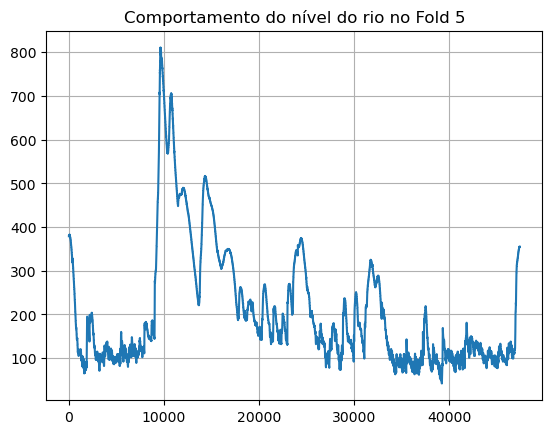

In [23]:
plt.plot(y_test_raw, label='Valores reais Fold 5')
plt.title("Comportamento do nível do rio no Fold 5")
plt.grid(True)
plt.show()


C:\Users\AdmPDI\AppData\Local\Temp\ipykernel_18000\3370427563.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  serie_plot = serie_plot.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')


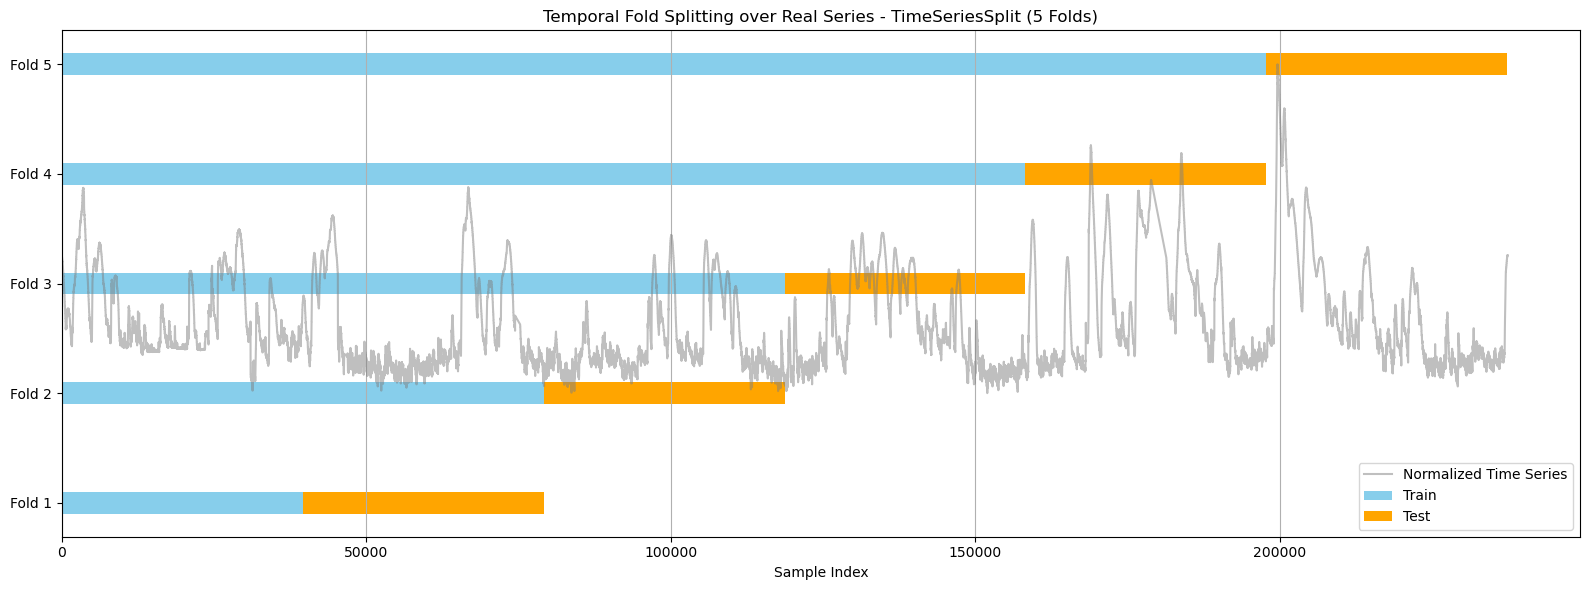

In [79]:
import matplotlib.pyplot as plt

# Garantir que 'Nível (cm)' esteja limpo
serie_plot = df1['Nível (cm)'].copy()
serie_plot = serie_plot.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')

# Normalização e escalonamento para visualização
serie_plot = (serie_plot - serie_plot.min()) / (serie_plot.max() - serie_plot.min())
serie_plot_scaled = serie_plot * 3 + 1

# Recalcula n com base na série final
n = len(serie_plot)

# Folds
fold_size = 39559
train_sizes = [39561, 79120, 118679, 158238, 197797]
test_starts = train_sizes
test_ends = [min(start + fold_size, n) for start in test_starts]

# Gráfico
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(range(n), serie_plot_scaled.values, color='grey', alpha=0.5, label='Normalized Time Series')

for i, (train_end, test_start, test_end) in enumerate(zip(train_sizes, test_starts, test_ends)):
    ax.barh(y=i, width=train_end, left=0, height=0.2, color='skyblue', label='Train' if i == 0 else "")
    ax.barh(y=i, width=test_end - test_start, left=test_start, height=0.2, color='orange', label='Test' if i == 0 else "")

ax.set_yticks(range(len(train_sizes)))
ax.set_yticklabels([f'Fold {i+1}' for i in range(len(train_sizes))])
ax.set_xlabel("Sample Index")
ax.set_title("Temporal Fold Splitting over Real Series - TimeSeriesSplit (5 Folds)")
ax.legend(loc='lower right')
ax.grid(True, axis='x')
plt.tight_layout()

# ✅ Exportar corretamente em Jupyter
fig.savefig("fold_split_plot.pdf", format='pdf', dpi=300)
plt.show()
